## Part A - Image Feature Extraction and Classification 


In [35]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [36]:
crack_path = "C:/Users/Admin/Desktop/Fundaments of ML DS605/ML_LAB6/448/Cracks"
non_crack_path = "C:/Users/Admin/Desktop/Fundaments of ML DS605/ML_LAB6/448/NonCracks"
image_size = (128,128)
files = os.listdir(crack_path)
image = cv2.imread(os.path.join(crack_path, files[0]))
print("Original image shape:", image.shape)
print("Height:", image.shape[0])
print("Width:", image.shape[1])
print("Channels:", image.shape[2])

Original image shape: (448, 448, 3)
Height: 448
Width: 448
Channels: 3


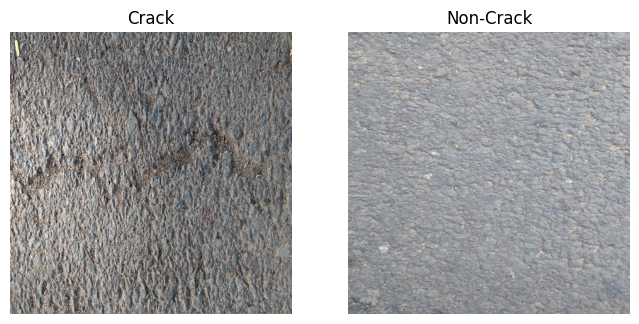

In [37]:
plt.figure(figsize=(8, 4))

image1 = cv2.imread(os.path.join(crack_path, os.listdir(crack_path)[0]))
image2 = cv2.imread(os.path.join(non_crack_path, os.listdir(non_crack_path)[0]))

image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Crack")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("Non-Crack")
plt.axis("off")

plt.show()

In [38]:
def extract_features(path, label):
    image = cv2.imread(path)
    if image is None:
        return None

    image = cv2.resize(image, image_size)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean = np.mean(gray)
    std = np.std(gray)
    minimum = np.min(gray)
    maximum = np.max(gray)
    median = np.median(gray)

    dark_ratio = np.sum(gray < 50) / gray.size
    bright_ratio = np.sum(gray > 200) / gray.size

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / gray.size

    return [
        mean, std, minimum, maximum, median,
        dark_ratio, bright_ratio,
        edge_count, edge_density, label
    ]

In [39]:
data = []
for filename in os.listdir(crack_path):
    if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        result = extract_features(os.path.join(crack_path, filename), 1)
        if result:
            data.append(result)


for filename in os.listdir(non_crack_path):

    if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        result = extract_features(os.path.join(non_crack_path, filename), 0)
        if result:
            data.append(result)

columns = [
    "mean",
    "std",
    "min",
    "max",
    "median",
    "dark_ratio",
    "bright_ratio",
    "edge_count",
    "edge_density",
    "label"
]

df = pd.DataFrame(data, columns=columns)

print("Dataset shape:", df.shape)
print(df.head())

df.to_csv("image_features.csv", index=False)

Dataset shape: (400, 10)
         mean        std  min  max  median  dark_ratio  bright_ratio  \
0  122.263977  33.070752   27  247   121.0    0.005859      0.014465   
1  131.565186  25.482184   13  252   133.0    0.003418      0.004456   
2  121.076355  31.130490    4  237   120.0    0.014221      0.010498   
3  130.309143  27.282676    8  251   131.0    0.002197      0.006592   
4  130.993286  27.639562   20  252   132.0    0.003357      0.007751   

   edge_count  edge_density  label  
0        5580      0.340576      1  
1        4579      0.279480      1  
2        4303      0.262634      1  
3        5507      0.336121      1  
4        5218      0.318481      1  


In [40]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


In [41]:
models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                     ("model", LogisticRegression(max_iter=1000))]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),
    "KNN": Pipeline([("scaler", StandardScaler()),("model", KNeighborsClassifier(n_neighbors=5))])
}

In [42]:
results = []
trained_models = {}

for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_time = time.perf_counter() - start

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        train_time, predict_time])

    trained_models[name] = model

results_df = pd.DataFrame(
    results,columns=[
        "Model","Accuracy","Precision","Recall",
        "F1-Score","Training Time","Prediction Time"])

print(results_df.round(4))
results_df.to_csv("model_results.csv", index=False)

                 Model  Accuracy  Precision  Recall  F1-Score  Training Time  \
0  Logistic Regression    0.9375     0.9268   0.950    0.9383         0.0134   
1        Decision Tree    0.9250     0.9250   0.925    0.9250         0.0042   
2        Random Forest    0.9500     0.9500   0.950    0.9500         0.1832   
3                  KNN    0.9500     0.9500   0.950    0.9500         0.0047   

   Prediction Time  
0           0.0014  
1           0.0011  
2           0.0089  
3           0.0082  


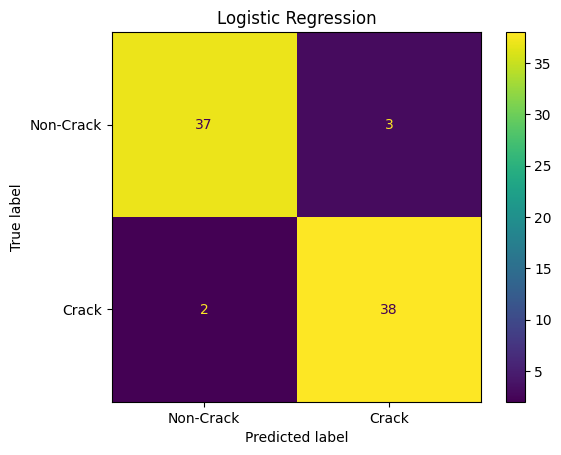

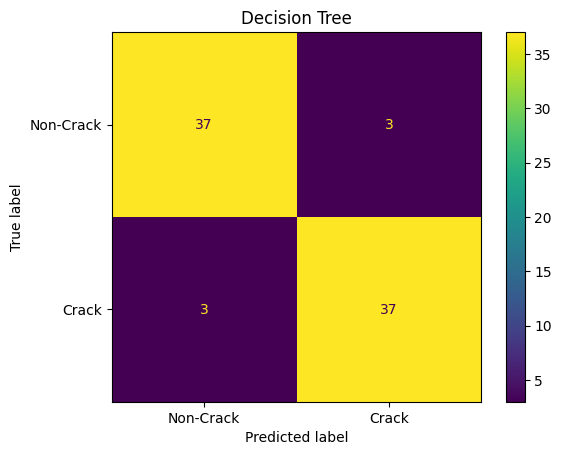

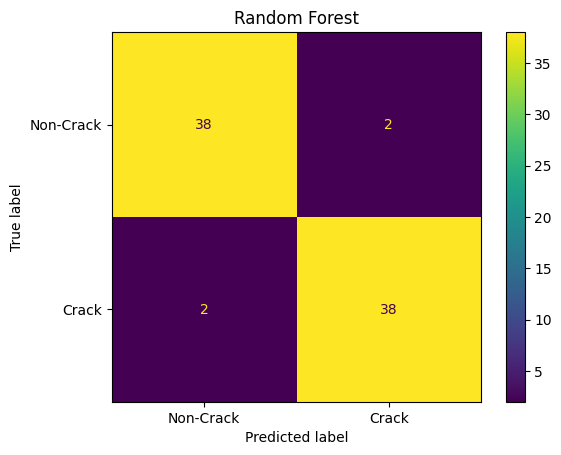

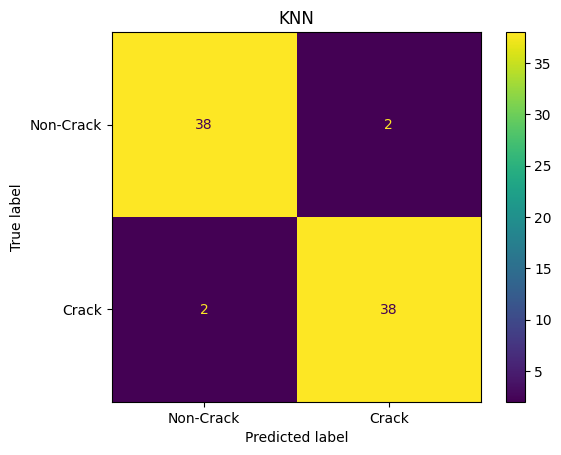

In [43]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Non-Crack", "Crack"])

    disp.plot()
    plt.title(name)
    plt.show()

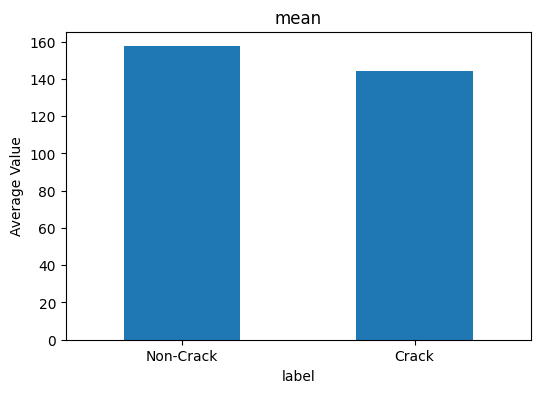

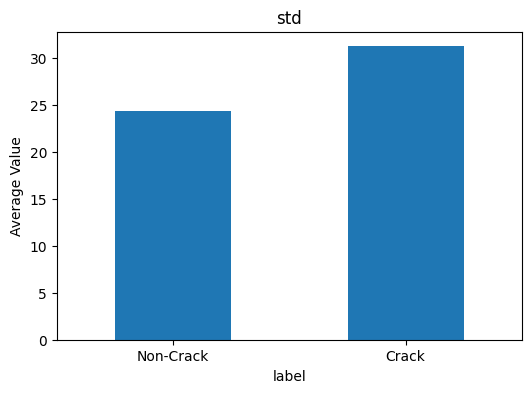

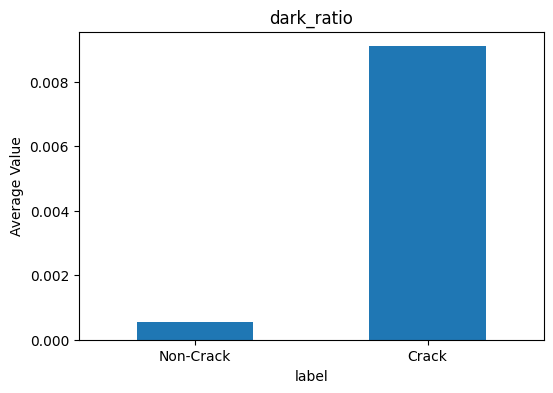

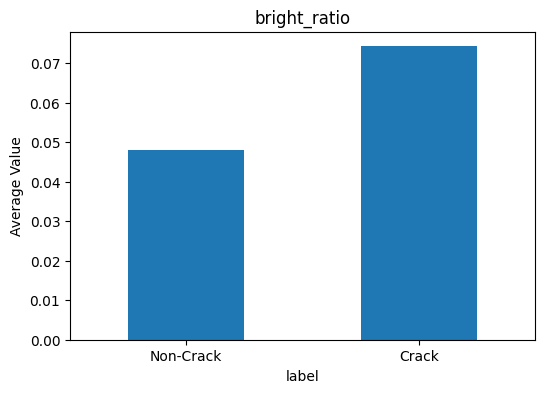

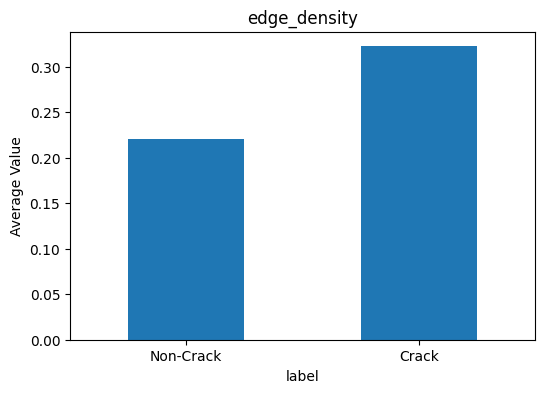

In [44]:
features = [
    "mean",
    "std",
    "dark_ratio",
    "bright_ratio",
    "edge_density"
]

for feature in features:

    plt.figure(figsize=(6, 4))

    df.groupby("label")[feature].mean().plot(kind="bar")

    plt.title(feature)
    plt.ylabel("Average Value")
    plt.xticks(
        [0, 1],
        ["Non-Crack", "Crack"],
        rotation=0
    )

    plt.show()

In [45]:
print("===== FINAL SUMMARY =====")
print("Total images:", len(df))
print("Training images:", len(X_train))
print("Testing images:", len(X_test))
print()

print("Class distribution:")
print(df["label"].value_counts())

print()
print("Model Performance:")
print(results_df.round(4))

===== FINAL SUMMARY =====
Total images: 400
Training images: 320
Testing images: 80

Class distribution:
label
1    200
0    200
Name: count, dtype: int64

Model Performance:
                 Model  Accuracy  Precision  Recall  F1-Score  Training Time  \
0  Logistic Regression    0.9375     0.9268   0.950    0.9383         0.0134   
1        Decision Tree    0.9250     0.9250   0.925    0.9250         0.0042   
2        Random Forest    0.9500     0.9500   0.950    0.9500         0.1832   
3                  KNN    0.9500     0.9500   0.950    0.9500         0.0047   

   Prediction Time  
0           0.0014  
1           0.0011  
2           0.0089  
3           0.0082  


# Task 1: Crack vs. Non-Crack Image Classification

## Dataset and Pipeline

- The dataset has 400 images (200 Crack, 200 Non-Crack), so it is perfectly balanced and accuracy is a fair metric.
- The images were originally 448×448 RGB. They were resized to 128×128 and converted to grayscale, so colour information was discarded.
- Each image is reduced to 9 hand-crafted features: mean, std, min, max, median, dark ratio, bright ratio, edge count and edge density.
- The split is 80/20 and stratified, giving 320 training and 80 test images (40 per class).

## Model Results

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Logistic Regression | 0.9375 | 0.9268 | 0.950 | 0.9383 |
| Decision Tree | 0.9250 | 0.9250 | 0.925 | 0.9250 |
| Random Forest | 0.9500 | 0.9500 | 0.950 | 0.9500 |
| KNN | 0.9500 | 0.9500 | 0.950 | 0.9500 |

- All four models score between 92.5% and 95%, so simple statistical and edge features separate cracks from non-cracks well.
- Random Forest and KNN tie for best (76/80 correct). Logistic Regression got 75/80 and Decision Tree 74/80.
- The test set is small, so one image changes accuracy by 1.25%. The gap between the best and worst model is only 1–2 images and may not be statistically meaningful.
- Decision Tree is the weakest, probably because a single tree overfits on 320 samples. Random Forest fixes this by averaging many trees.
- Logistic Regression has slightly higher recall than precision (0.95 vs 0.927). It catches most cracks but has a few more false alarms.

## Efficiency

| Model | Training Time (s) | Prediction Time (s) |
|---|---|---|
| Logistic Regression | 0.0134 | 0.0014 |
| Decision Tree | 0.0042 | 0.0011 |
| Random Forest | 0.1832 | 0.0089 |
| KNN | 0.0047 | 0.0082 |

- Random Forest is the slowest to train (~0.18 s), roughly 40× slower than Decision Tree and KNN, for the same accuracy as KNN.
- KNN trains almost instantly because it only stores the data. Its prediction time is higher than Logistic Regression's and the Decision Tree's, and it would grow with larger data.
- Given equal accuracy, KNN is the most practical choice here. Random Forest would be preferred if robustness mattered more than speed.

## Feature Insight

- Edge density is around 0.26–0.34 in the sample rows. That is high, which means the Canny thresholds (100/200) also pick up surface texture, not just crack lines. This could explain the remaining errors.
- Crack surfaces tend to have more dark pixels (shadows in the crack) and higher contrast, so `dark_ratio`, `std` and `edge_density` are the most likely discriminating features. The bar plots compare them by class.

## Limitations

- Only global grayscale statistics are used, so there is no spatial or shape information. A crack is a thin line structure.
- There is no cross-validation, only a single split.
- Adding texture features (LBP, HOG) or using a CNN would likely push accuracy higher.

## Conclusion

A simple pipeline of hand-crafted features plus a basic classifier reaches about 93–95% accuracy. Model choice matters little; the features are the limiting factor.